Searching over model order
In this exercise you are faced with a dataset which appears to be an ARMA model. You can see the ACF and PACF in the plot below. In order to choose the best order for this model you are going to have to do a search over lots of potential model orders to find the best set.


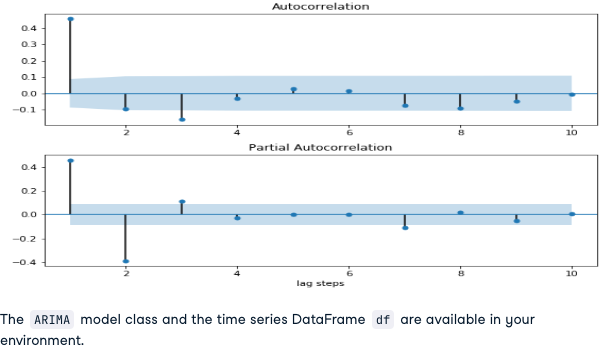

- Loop over values of p from 0-2.
- Loop over values of q from 0-2.
- Train and fit an ARMA(p,q) model.
- Append a tuple of (p,q, AIC value, BIC value) to order_aic_bic.

In [ ]:
# Create empty list to store search results
order_aic_bic=[]

# Loop over p values from 0-2
for p in range(3):
  # Loop over q values from 0-2
    for q in range(3):
      	# create and fit ARMA(p,q) model
        model = ARIMA(df, order=(p,0,q))
        results = model.fit()
        
        # Append order and results tuple
        order_aic_bic.append((p,q, results.aic, results.bic))

- Create a DataFrame to hold the order search information in the order_aic_bic list. Give it the column names ['p', 'q', 'AIC', 'BIC'].
- Print the DataFrame in order of increasing AIC and then BIC.



In [ ]:
# Construct DataFrame from order_aic_bic
order_df = pd.DataFrame(order_aic_bic, 
                        columns=['p', 'q', 'AIC', 'BIC'])

# Print order_df in order of increasing AIC
print(order_df.sort_values('AIC'))

# Print order_df in order of increasing BIC
print(order_df.sort_values('BIC'))
   p  q       AIC       BIC
7  2  1  1414.249  1431.107
8  2  2  1416.085  1437.158
5  1  2  1417.030  1433.888
6  2  0  1419.109  1431.753
2  0  2  1425.057  1437.701
4  1  1  1428.052  1440.696
1  0  1  1429.989  1438.418
3  1  0  1497.308  1505.737
0  0  0  1615.494  1619.708

   p  q       AIC       BIC
7  2  1  1414.249  1431.107
6  2  0  1419.109  1431.753
5  1  2  1417.030  1433.888
8  2  2  1416.085  1437.158
2  0  2  1425.057  1437.701
1  0  1  1429.989  1438.418
4  1  1  1428.052  1440.696
3  1  0  1497.308  1505.737
0  0  0  1615.494  1619.708

ARMA(2,1) is best fit

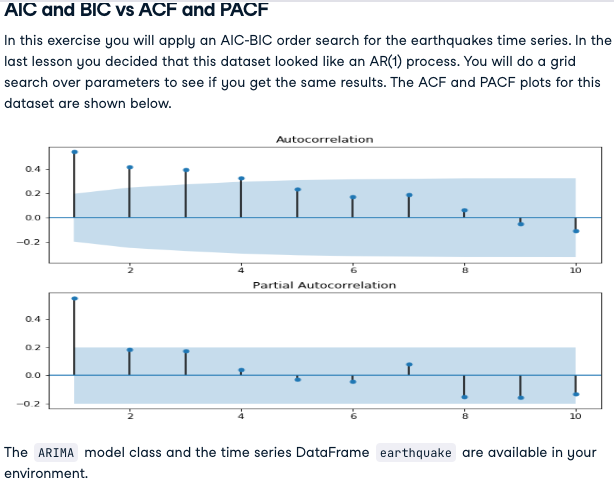

- Loop over orders of p and q between 0 and 2.
- Inside the loop try to fit an ARMA(p,q) to earthquake on each loop.
- Print p and q alongside AIC and BIC in each loop.
- If the model fitting procedure fails print p, q, None, None.

In [ ]:
# Loop over p values from 0-2
for p in range(3):
    # Loop over q values from 0-2
    for q in range(3):
      
        try:
            # create and fit ARMA(p,q) model
            model = ARIMA(earthquake, order=(p,0,q))
            results = model.fit()
            
            # Print order and results
            print(p, q, results.aic, results.bic)
            
        except:
            print(p, q, None, None)     

    0 0 676.5443594984636 681.7345991987328
    0 1 654.8468586200252 662.6322181704289
    0 2 651.733227051897 662.1137064524353
    1 0 643.9676770992027 651.7530366496064
    1 1 640.4562835911981 650.8367629917365
    1 2 642.3808673565673 655.3564666072402
    2 0 642.7338539385339 653.1143333390722
    2 1 647.4406643641798 660.4162636148528
    2 2 642.4685896288877 658.0393087296952